# Importação dos dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/elber/#Cursos/##FIAP/8IADT-FASE1-TECHCHALLENGE/data/DENGBR25.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3138684972.py:3: DtypeWarning: Columns (22,44,45,46,54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/elber/#Cursos/##FIAP/8IADT-FASE1-TECHCHALLENGE/data/DENGBR25.csv')


Mensagem de leitura:<p>
*DtypeWarning: Columns (22,44,45,46,54) have mixed types. Specify dtype option on import or set low_memory=False.*

**TODO:**
<p>-Resolver tipos misturados nas colunas abaixo:
<p>22   ID_OCUPA_N  object --> descartado
<p>44   DT_CHIK_S1  object --> descartado
<p>45   DT_CHIK_S2  object --> descartado
<p>46   DT_PRNT     object --> descartado
<p>54   DT_VIRAL    object --> descartado
<p>Ja seriam descartados

In [ ]:
df.shape

(1605624, 121)

In [ ]:
#Lista detalhada dos tipos das colunas
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1605624 entries, 0 to 1605623
Columns: 121 entries, TP_NOT to MIGRADO_W
dtypes: float64(92), int64(10), object(19)
memory usage: 1.4+ GB


df.info()
<p>Resultado:

*<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1605624 entries, 0 to 1605623
<p>Columns: 121 entries, TP_NOT to MIGRADO_W
<p>memory usage: 1.4+ GB*
<p>dtypes: float64(92), int64(10), object(19) - Quantidade dos tipos de colunas

**TODO**:
<p>-Verificar as colunas com tipo Object
<p>-Para a mesma coluna

*   se existe campo vazio
*   se existe campo com tipos diferentes





# Registros Duplicados(1)

---
Primeira analise antes do tratamento de registros duplicados


In [ ]:
# Conta TOTAL de registros duplicados
total_duplicados = df.duplicated().sum()
print(f"Registros duplicados: {total_duplicados}")

# Mostra APENAS os registros duplicados
duplicados = df[df.duplicated()]
print("Registros duplicados:")
print(duplicados)

# Mostra índices das linhas duplicadas
indices_duplicados = df[df.duplicated()].index
print(f"Índices duplicados: {indices_duplicados.tolist()}")


Registros duplicados: 660
Registros duplicados:
         TP_NOT ID_AGRAVO  DT_NOTIFIC  SEM_NOT  NU_ANO  SG_UF_NOT  ID_MUNICIP  \
4474          2       A90  2025-02-13   202507    2025         12      120040   
5009          2       A90  2025-03-21   202512    2025         12      120020   
8032          2       A90  2025-02-23   202509    2025         12      120040   
8559          2       A90  2025-11-11   202546    2025         12      120020   
13766         2       A90  2025-08-08   202532    2025         27      270430   
...         ...       ...         ...      ...     ...        ...         ...   
1597590       2       A90  2025-03-06   202510    2025         35      352920   
1599702       2       A90  2025-01-09   202502    2025         35      353070   
1600455       2       A90  2025-02-20   202508    2025         35      351370   
1603910       2       A90  2025-07-01   202527    2025         35      353760   
1604323       2       A90  2025-11-12   202546    2025       

In [ ]:
#Retorna a matriz toda, informando se o campo é nulo ou nao
#df.isnull()

#Retorna o nome da coluna e se todos os elementos dela sao nulos
#all - retorna se toda a coluna tem valor true
#df.isnull().all()


# Analise de colunas/itens vazios

In [ ]:
# Encontra colunas onde todos os valores são NaN (vazias)
colunas_vazias = df.columns[df.isnull().all()].tolist()
print("Colunas vazias:", colunas_vazias)
print(f"Total: {len(colunas_vazias)} colunas")


Colunas vazias: ['DOENCA_TRA', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'MIGRADO_W']
Total: 15 colunas


***Colunas Vazias***
<p>Colunas vazias: ['DOENCA_TRA', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'MIGRADO_W']

***Analisando as colunas***
<p>DOENCA_TRA
<p>MANI_HEMOR
<p>EPISTAXE
<p>GENGIVO
<p>METRO - ver grav_metro
<p>PETEQUIAS
<p>HEMATURA
<p>SANGRAM - ver alrm_sang, grav_sang
<p>LACO_N - ver laco
<p>PLASMATICO
<p>EVIDENCIA
<p>PLAQ_MENOR - ver alrm_plaq
<p>CON_FHD
<p>COMPLICA
<p>MIGRADO_W

Total: 15 colunas


In [ ]:
#Qual coluna apresenta pelo menos 1 valor vazio
colunas_com_algum_nulos = df.columns[df.isnull().any()].tolist()
print("Colunas com algum valor vazio:", colunas_com_algum_nulos)
print(f"Total: {len(colunas_com_algum_nulos)} colunas")


Colunas com algum valor vazio: ['ID_REGIONA', 'ID_UNIDADE', 'ANO_NASC', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'ID_MN_RESI', 'ID_RG_RESI', 'DT_INVEST', 'ID_OCUPA_N', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE', 'DT_CHIK_S1', 'DT_CHIK_S2', 'DT_PRNT', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'DT_SORO', 'RESUL_SORO', 'DT_NS1', 'RESUL_NS1', 'DT_VIRAL', 'RESUL_VI_N', 'DT_PCR', 'RESUL_PCR_', 'SOROTIPO', 'HISTOPA_N', 'IMUNOH_N', 'HOSPITALIZ', 'DT_INTERNA', 'UF', 'MUNICIPIO', 'TPAUTOCTO', 'COUFINF', 'COPAISINF', 'COMUNINF', 'CLASSI_FIN', 'CRITERIO', 'DOENCA_TRA', 'CLINC_CHIK', 'EVOLUCAO', 'DT_OBITO', 'DT_ENCERRA', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'DT_ALRM', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV

In [ ]:
#Valores distintos presentes em cada coluna (mostra os 5 primeiros valores)
def listar_colunas_distinct(df, max_colunas=15):
    """Lista nome da coluna + valores únicos para cada uma"""
    print(f"{'COLUNA':<25} {'VALORES ÚNICOS (amostra)':<40} {'TOTAL'}")
    print("-" * 80)

    for i, coluna in enumerate(df.columns[:max_colunas]):
        unicos = df[coluna].unique()
        amostra = list(unicos[:5])  # Primeiros 5 valores
        print(f"{coluna:<25} {str(amostra):<40} {len(unicos):>5}")

    print(f"\n... e mais {len(df.columns) - max_colunas} colunas")

# Execute:
listar_colunas_distinct(df, 121)


COLUNA                    VALORES ÚNICOS (amostra)                 TOTAL
--------------------------------------------------------------------------------
TP_NOT                    [np.int64(2)]                                1
ID_AGRAVO                 ['A90']                                      1
DT_NOTIFIC                ['2025-01-06', '2025-01-13', '2025-02-19', '2025-03-17', '2025-04-06']   329
SEM_NOT                   [np.int64(202502), np.int64(202503), np.int64(202508), np.int64(202512), np.int64(202515)]    47
NU_ANO                    [np.int64(2025), np.int64(2024)]             2
SG_UF_NOT                 [np.int64(12), np.int64(51), np.int64(50), np.int64(52), np.int64(35)]    27
ID_MUNICIP                [np.int64(120020), np.int64(120033), np.int64(120030), np.int64(120050), np.int64(120060)]  4742
ID_REGIONA                [np.float64(1941.0), np.float64(1940.0), np.float64(1939.0), np.float64(1938.0), np.float64(1937.0)]   315
ID_UNIDADE                [np.float64(2000

In [ ]:
# Configura para mostrar todas as colunas (121 no seu caso)
pd.set_option('display.max_columns', None)

# Agora todas as colunas aparecerão
df.head(10)


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2025-01-06,202502,2025,12,120020,1941.0,2000202.0,2025-01-01,202501,1965.0,4059,F,5.0,4.0,NaN,12,120020.0,1941.0,1,2025-01-06,NaN,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-06,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,NaN,NaN,1.0,NaN,2025-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2025-01-08,0,NaN,NaN
1,2,A90,2025-01-13,202503,2025,12,120020,1941.0,2002914.0,2025-01-11,202502,1988.0,4036,M,6.0,4.0,8.0,12,120020.0,1941.0,1,2025-01-13,NaN,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-13,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,NaN,NaN,1.0,NaN,2025-01-29,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2025-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2025-01-15,0,NaN,NaN
2,2,A90,2025-02-19,202508,2025,12,120020,1941.0,2000202.0,2025-02-14,202507,1994.0,4030,F,5.0,4.0,NaN,12,120020.0,1941.0,1,2025-02-19,NaN,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,NaN,NaN,1.0,NaN,2025-05-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2025-05-05,0,NaN,NaN
3,2,A90,2025-03-17,202512,2025,12,120020,1941.0,5336171.0,2025-03-16,202512,1997.0,4028,M,6.0,4.0,NaN,12,120020.0,1941.0,1,2025-03-17,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-26,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2025-03-17,12.0,120020.0,NaN,NaN,NaN,NaN,10.0,1.0,NaN,NaN,1.0,NaN,2025-06-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2025-03-24,1,NaN,NaN
4,2,A90,2025-04-06,202515,2025,12,120020,1941.0,5336171.0,2025-03-25,202513,1997.0,4028,M,6.0,4.0,NaN,12,120020.0,1941.0,1,2025-04-06,NaN,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-26,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,NaN,NaN,1.0,NaN,2025-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2025-06-18,1,NaN,NaN
5,2,A90,2025-04-09,202515,2025,12,120020,1941.0,5336171.0,2025-04-05,20

## Eliminando as colunas vazias ou com apenas 1 valor

In [ ]:
#Drop das colunas vazias (NaN)
cols_para_excluir = [
"TP_NOT","ID_AGRAVO","DT_NOTIFIC","SEM_NOT","NU_ANO","SG_UF_NOT","ID_MUNICIP","ID_REGIONA","ID_UNIDADE","DT_SIN_PRI","SEM_PRI","ANO_NASC","CS_GESTANT","CS_RACA","CS_ESCOL_N","SG_UF",
                "ID_MN_RESI","ID_RG_RESI","ID_PAIS","DT_INVEST","ID_OCUPA_N","DT_CHIK_S1","DT_CHIK_S2","DT_PRNT","RES_CHIKS1","RES_CHIKS2","RESUL_PRNT","DT_SORO","DT_NS1","DT_VIRAL",
                "DT_PCR","DT_INTERNA","UF","MUNICIPIO","TPAUTOCTO","COUFINF","COPAISINF","COMUNINF","CLASSI_FIN","CRITERIO","DOENCA_TRA","CLINC_CHIK","EVOLUCAO","DT_OBITO","DT_ENCERRA",
                "DT_ALRM","GRAV_PULSO","GRAV_CONV","GRAV_ENCH","GRAV_INSUF","GRAV_TAQUI","GRAV_EXTRE","GRAV_HIPOT","GRAV_HEMAT","GRAV_MELEN","GRAV_METRO","GRAV_SANG","GRAV_AST","GRAV_MIOC",
                "GRAV_CONSC","GRAV_ORGAO","DT_GRAV","MANI_HEMOR","EPISTAXE","GENGIVO","METRO","PETEQUIAS","HEMATURA","SANGRAM","LACO_N","PLASMATICO","EVIDENCIA","PLAQ_MENOR","CON_FHD","COMPLICA",
                "TP_SISTEMA","NDUPLIC_N","DT_DIGITA","CS_FLXRET","FLXRECEBI","MIGRADO_W"
]

df = df.drop(columns=cols_para_excluir, errors="ignore")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1605624 entries, 0 to 1605623
Data columns (total 40 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   NU_IDADE_N  1605624 non-null  int64  
 1   CS_SEXO     1605624 non-null  object 
 2   FEBRE       1538181 non-null  float64
 3   MIALGIA     1538181 non-null  float64
 4   CEFALEIA    1538181 non-null  float64
 5   EXANTEMA    1538181 non-null  float64
 6   VOMITO      1538181 non-null  float64
 7   NAUSEA      1538181 non-null  float64
 8   DOR_COSTAS  1538181 non-null  float64
 9   CONJUNTVIT  1538181 non-null  float64
 10  ARTRITE     1538181 non-null  float64
 11  ARTRALGIA   1538181 non-null  float64
 12  PETEQUIA_N  1538181 non-null  float64
 13  LEUCOPENIA  1538181 non-null  float64
 14  LACO        1538181 non-null  float64
 15  DOR_RETRO   1538181 non-null  float64
 16  DIABETES    1538181 non-null  float64
 17  HEMATOLOG   1538181 non-null  float64
 18  HEPATOPAT   1538181 no

# Criando copia de df --> df_novo

In [ ]:
df_novo = df.copy(deep='true')

# Tratando o Rotulo **HOSPITALIZ**
<p>Descrição: Informa se ocorreu hospitalização
<p>Tipo: float64
<p>Valores no Dicionario de Dados: 1-Sim 2-Não 9-Ignorado
<p>Valores na base:  [np.float64(2.0), np.float64(nan), np.float64(1.0), np.float64(9.0)]  --> Total: 4

<p>

Como a interpretação do rotulo que queremos é **Grave** ou **NAO Grave**, adotaremos a seguinte conversao:

| Valor original | Significado | Novo valor | Justificativa |
|  ------------- | ----------- | ---------- | ------------- |
| 1.0 |	Sim |	1 |	Manter positivo |
| 2.0 | Não |	0 |	Padrão binário |
| 9.0 |	Ignorado |	0 |	Não é "Sim" |
| NaN |	Nulo |	0 |	Não é "Sim |

In [ ]:
#troco o 2(Nao) para 0
df_novo['HOSPITALIZ'] = df_novo['HOSPITALIZ'].replace(2, 0)

#troco o 9(ignorado) por 0
df_novo['HOSPITALIZ'] = df_novo[['HOSPITALIZ']].replace(9, 0)

#troco o NAN por 0
df_novo['HOSPITALIZ'] = df_novo[['HOSPITALIZ']].fillna(0)

<Axes: ylabel='Frequency'>

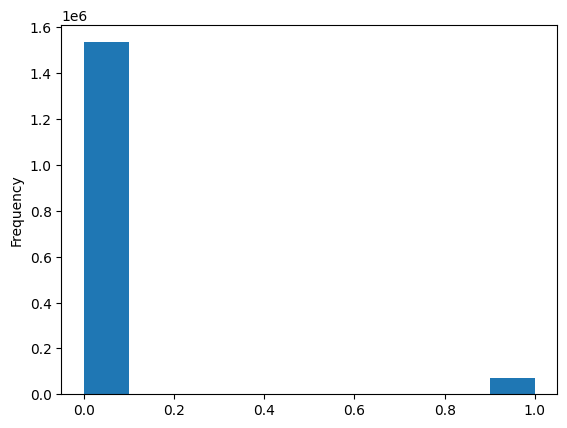

In [ ]:
df_novo['HOSPITALIZ'].plot(kind='hist')

As bolinhas indicam os outliers

<Axes: >

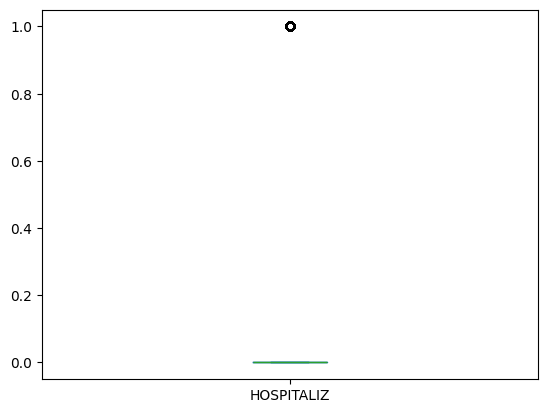

In [ ]:
df_novo['HOSPITALIZ'].plot(kind='box')

In [ ]:
df_novo['HOSPITALIZ'].describe()

,HOSPITALIZ
count,1.605624e+06
mean,4.373938e-02
std,2.045147e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.000000e+00


| Estatística | Valor         | Interpretação |
|--------------|----------------|----------------|
| count | 1.605624e+06 | 1.605.624 valores não-nulos (total de linhas válidas) |
| mean  | 4.373938e-02 | 0.0438 (4,38% das linhas são 1 / “Sim”) |
| std   | 2.045147e-01 | 0.2045 (desvio padrão baixo = pouca variação) |
| min   | 0.000000e+00 | 0 (valor mínimo) |
| 25%   | 0.000000e+00 | 25% dos dados ≤ 0 |
| 50%   | 0.000000e+00 | Mediana = 0 (metade dos dados é 0) |
| 75%   | 0.000000e+00 | 75% dos dados ≤ 0 |
| max   | 1.000000e+00 | 1 (valor máximo) |

<p>
std: 0.2045 (20,45%)
<p>
mean: 0.0438 (4,38%)

----------
count: Número de valores não-nulos

mean: Média aritmética

std: Desvio padrão

min: Valor mínimo

25%: 1º quartil (Q1)

50%: Mediana (Q2)

75%: 3º quartil (Q3)

max: Valor máximo
------------


  ## Seus dados estão assim distribuídos:

95,6% → 0 (muito próximos da média)
4,4% → 1 (poucos afastados)

| Desvio Padrão | Significado         | Seus dados |
| ------------- | ------------------- | ---------- |
| 0             | Todos iguais        | -          |
| 0-0.3         | Baixo (concentrado) | ✅ 0.20     |
| 0.3-0.7       | Médio               | -          |
| >0.7          | Alto (espalhado)    | -          |

<p>68% dos dados estão entre: 0.0438 ± 0.20 → -0.16 a 0.24
<p>99,7% entre: 0.0438 ± 3×0.20 → -0.56 a 0.64


# Tratando as colunas não FLOAT

In [ ]:
set(df['CS_SEXO'])

{'F', 'I', 'M'}

### **CS_SEXO**
<p>1   CS_SEXO     1605624 non-null  object
<p>CS_SEXO                   ['F', 'M', 'I']                              3

***Eliminando o valor I***

In [ ]:
# ANTES
print("=== ANTES ===")
print(df_novo['CS_SEXO'].value_counts())

# EXCLUIR linhas com 'I'
df_novo = df_novo[df_novo['CS_SEXO'] != 'I']

# DEPOIS
print("\n=== DEPOIS ===")
print(df_novo['CS_SEXO'].value_counts())
print(f"Linhas removidas: {len(df_novo['CS_SEXO'])}")  # se tiver original_size


=== ANTES ===
CS_SEXO
F    872553
M    731870
I      1201
Name: count, dtype: int64

=== DEPOIS ===
CS_SEXO
F    872553
M    731870
Name: count, dtype: int64
Linhas removidas: 1604423


***Transformando para binario***

In [ ]:
#df_novo['CS_SEXO'] = df_novo['CS_SEXO'].replace('F', 1.0 ).astype(float)
#df_novo['CS_SEXO'] = df_novo['CS_SEXO'].replace('M', 0.0).astype(float)

df_novo['CS_SEXO'] = df_novo['CS_SEXO'].map({'F': 1.0, 'M': 0.0}).astype(float)


In [ ]:
df_novo['CS_SEXO'].value_counts()

,count
CS_SEXO,
1.0,872553
0.0,731870


In [ ]:
df_novo.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1604423 entries, 0 to 1605623
Data columns (total 40 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   NU_IDADE_N  1604423 non-null  int64  
 1   CS_SEXO     1604423 non-null  float64
 2   FEBRE       1537015 non-null  float64
 3   MIALGIA     1537015 non-null  float64
 4   CEFALEIA    1537015 non-null  float64
 5   EXANTEMA    1537015 non-null  float64
 6   VOMITO      1537015 non-null  float64
 7   NAUSEA      1537015 non-null  float64
 8   DOR_COSTAS  1537015 non-null  float64
 9   CONJUNTVIT  1537015 non-null  float64
 10  ARTRITE     1537015 non-null  float64
 11  ARTRALGIA   1537015 non-null  float64
 12  PETEQUIA_N  1537015 non-null  float64
 13  LEUCOPENIA  1537015 non-null  float64
 14  LACO        1537015 non-null  float64
 15  DOR_RETRO   1537015 non-null  float64
 16  DIABETES    1537015 non-null  float64
 17  HEMATOLOG   1537015 non-null  float64
 18  HEPATOPAT   1537015 non-nul

### **NU_IDADE_N**

<p>0   NU_IDADE_N  1605624 non-null  int64  

<p>NU_IDADE_N                [np.int64(4059), np.int64(4036), np.int64(4030), np.int64(4028), np.int64(4023)]   235

1. Hora
2. Dia
3. Mês
4. Ano

Ex: 3009  = 3 (mes) + 009 (numero) = nove meses
4018  = 4(ano) + 018 = dezoito anos

In [ ]:
import pandas as pd
import numpy as np

def converter_idade_para_anos(df: pd.DataFrame, coluna_idade: str, nova_coluna: str = 'idade_anos') -> pd.DataFrame:
    """
    Converte coluna de idade codificada (4 dígitos) para anos em float.

    Parâmetros:
    - df: DataFrame com a coluna de idade codificada
    - coluna_idade: Nome da coluna com códigos de 4 dígitos (str)
    - nova_coluna: Nome da nova coluna com idade em anos (default: 'idade_anos')

    Retorna:
    - DataFrame com nova coluna de idade em anos e print de comparação
    """

    # Converte para string e pad com zeros à esquerda para garantir 4 dígitos
    df[coluna_idade] = df[coluna_idade].astype(str).str.zfill(4)

    # Extrai tipo (1º dígito) e valor (próximos 3 dígitos)
    df['tipo'] = df[coluna_idade].str[0].astype(int)
    df['valor'] = df[coluna_idade].str[1:].astype(int)

    # Converte para anos baseado no tipo
    def para_anos(tipo, valor):
        if tipo == 1:  # Hora -> divide por horas no ano (365.25 * 24)
            return valor / (365.25 * 24)
        elif tipo == 2:  # Dia -> divide por dias no ano (365.25)
            return valor / 365.25
        elif tipo == 3:  # Mês -> divide por 12
            return valor / 12
        elif tipo == 4:  # Ano
            return float(valor)
        else:
            return np.nan

    df[nova_coluna] = df.apply(lambda row: para_anos(row['tipo'], row['valor']), axis=1)

    # Exibe comparação dos primeiros 10 registros (ou todos se < 10)
    n_mostrar = min(10, len(df))
    print("COMPARAÇÃO VALOR ANTERIOR vs. ATUAL (primeiros {} registros):".format(n_mostrar))
    print("=" * 60)
    comparacao = df[[coluna_idade, nova_coluna]].head(n_mostrar)
    for idx, row in comparacao.iterrows():
        print(f"Original: {row[coluna_idade]:4s} → Anos: {row[nova_coluna]:.3f}")

    # Remove colunas auxiliares
    df.drop(['tipo', 'valor'], axis=1, inplace=True)

    return df


# Adicionando indice para as linhas

In [ ]:
#adicionando um indice em df_novo
df_novo['indice'] = range(len(df_novo))

# Convertendo as idades

In [ ]:
df_novo = converter_idade_para_anos(df_novo, 'NU_IDADE_N', 'idade_codificada')

COMPARAÇÃO VALOR ANTERIOR vs. ATUAL (primeiros 10 registros):
Original: 4059 → Anos: 59.000
Original: 4036 → Anos: 36.000
Original: 4030 → Anos: 30.000
Original: 4028 → Anos: 28.000
Original: 4028 → Anos: 28.000
Original: 4028 → Anos: 28.000
Original: 4028 → Anos: 28.000
Original: 4023 → Anos: 23.000
Original: 4024 → Anos: 24.000
Original: 4030 → Anos: 30.000


In [ ]:
df_novo.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1604423 entries, 0 to 1605623
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   NU_IDADE_N        1604423 non-null  object 
 1   CS_SEXO           1604423 non-null  float64
 2   FEBRE             1537015 non-null  float64
 3   MIALGIA           1537015 non-null  float64
 4   CEFALEIA          1537015 non-null  float64
 5   EXANTEMA          1537015 non-null  float64
 6   VOMITO            1537015 non-null  float64
 7   NAUSEA            1537015 non-null  float64
 8   DOR_COSTAS        1537015 non-null  float64
 9   CONJUNTVIT        1537015 non-null  float64
 10  ARTRITE           1537015 non-null  float64
 11  ARTRALGIA         1537015 non-null  float64
 12  PETEQUIA_N        1537015 non-null  float64
 13  LEUCOPENIA        1537015 non-null  float64
 14  LACO              1537015 non-null  float64
 15  DOR_RETRO         1537015 non-null  float64
 16  DIABE

In [ ]:
# linhas onde idade_codificada é NaN, retornando só a coluna 'indice'
indices_nulos = df_novo.loc[df_novo['idade_codificada'].isna(), 'indice']

print(indices_nulos)


581282      580714
582515      581945
665074      664469
1220895    1219923
Name: indice, dtype: int64


## Excluindo NU_IDADE_N e as idades vazias

In [ ]:
df_novo.drop(columns=['NU_IDADE_N'], inplace=True)
df_novo.dropna(subset=['idade_codificada'], inplace=True)
df_novo.info(verbose='true', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1604419 entries, 0 to 1605623
Data columns (total 41 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CS_SEXO           1604419 non-null  float64
 1   FEBRE             1537011 non-null  float64
 2   MIALGIA           1537011 non-null  float64
 3   CEFALEIA          1537011 non-null  float64
 4   EXANTEMA          1537011 non-null  float64
 5   VOMITO            1537011 non-null  float64
 6   NAUSEA            1537011 non-null  float64
 7   DOR_COSTAS        1537011 non-null  float64
 8   CONJUNTVIT        1537011 non-null  float64
 9   ARTRITE           1537011 non-null  float64
 10  ARTRALGIA         1537011 non-null  float64
 11  PETEQUIA_N        1537011 non-null  float64
 12  LEUCOPENIA        1537011 non-null  float64
 13  LACO              1537011 non-null  float64
 14  DOR_RETRO         1537011 non-null  float64
 15  DIABETES          1537011 non-null  float64
 16  HEMAT

# Analise das colunas duvidosas



## Analise dos valores nos campos

In [ ]:
# dropna=False: Inclui os valores NaN na contagem
# ​normalize=True: Retorna as proporções (frações) ao invés de contagens absolutas
# .round(4) * 100: Arredonda para 4 casas decimais e converte para porcentagem (%)

#1-DEN 1 2-DEN 2 3 DEN 3 4-DEN 4
df_novo['SOROTIPO'].value_counts(dropna=False, normalize=True).round(4) * 100

,proportion
SOROTIPO,
NaN,97.08
2.0,2.16
3.0,0.41
1.0,0.35
4.0,0.00


SOROTIPO -  apresenta 97.08 = NaN

In [ ]:
#1-Reagente 2-Não Reagente 3-Inconclusivo 4-Não realizado
df_novo['HISTOPA_N'].value_counts(dropna=False, normalize=True).round(4) * 100

,proportion
HISTOPA_N,
NaN,58.42
4.0,41.48
2.0,0.06
3.0,0.03
1.0,0.02


HISTOPA_N - apresenta >99% de NaN e Não realizado

In [ ]:
#1-Reagente 2-Não Reagente 3-Inconclusivo 4-Não realizado
df_novo['IMUNOH_N'].value_counts(dropna=False, normalize=True).round(4) * 100

,proportion
IMUNOH_N,
NaN,58.40
4.0,41.46
2.0,0.07
3.0,0.05
1.0,0.02


IMUNOH_N - apresenta >99% de NaN e Não realizado

## Exclusao dos campos

In [ ]:
df_novo = df_novo.drop(columns=["SOROTIPO", "HISTOPA_N", "IMUNOH_N"], errors="ignore")

In [ ]:
df_novo.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1604419 entries, 0 to 1605623
Data columns (total 38 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CS_SEXO           1604419 non-null  float64
 1   FEBRE             1537011 non-null  float64
 2   MIALGIA           1537011 non-null  float64
 3   CEFALEIA          1537011 non-null  float64
 4   EXANTEMA          1537011 non-null  float64
 5   VOMITO            1537011 non-null  float64
 6   NAUSEA            1537011 non-null  float64
 7   DOR_COSTAS        1537011 non-null  float64
 8   CONJUNTVIT        1537011 non-null  float64
 9   ARTRITE           1537011 non-null  float64
 10  ARTRALGIA         1537011 non-null  float64
 11  PETEQUIA_N        1537011 non-null  float64
 12  LEUCOPENIA        1537011 non-null  float64
 13  LACO              1537011 non-null  float64
 14  DOR_RETRO         1537011 non-null  float64
 15  DIABETES          1537011 non-null  float64
 16  HEMAT

# Tratamento dos campos com valores NaN

In [ ]:
colunas_binarias = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO',
    'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA',
    'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO',
    'DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL',
    'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE',
    'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG',
    'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR',
    'ALRM_HEPAT', 'ALRM_LIQ'
]


# Usa replace() em vez de map() para DataFrame
df_novo[colunas_binarias] = df_novo[colunas_binarias].replace({2.0: 0.0}).fillna(0.0)

In [ ]:
colunas_nao_binarias = ['RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_']
df_novo[colunas_nao_binarias] = df_novo[colunas_nao_binarias].fillna(4.0)

In [ ]:
df_novo.info(verbose='true', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1604419 entries, 0 to 1605623
Data columns (total 38 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   CS_SEXO           1604419 non-null  float64
 1   FEBRE             1604419 non-null  float64
 2   MIALGIA           1604419 non-null  float64
 3   CEFALEIA          1604419 non-null  float64
 4   EXANTEMA          1604419 non-null  float64
 5   VOMITO            1604419 non-null  float64
 6   NAUSEA            1604419 non-null  float64
 7   DOR_COSTAS        1604419 non-null  float64
 8   CONJUNTVIT        1604419 non-null  float64
 9   ARTRITE           1604419 non-null  float64
 10  ARTRALGIA         1604419 non-null  float64
 11  PETEQUIA_N        1604419 non-null  float64
 12  LEUCOPENIA        1604419 non-null  float64
 13  LACO              1604419 non-null  float64
 14  DOR_RETRO         1604419 non-null  float64
 15  DIABETES          1604419 non-null  float64
 16  HEMAT

# Registros Duplicados(2)

---
Segunda analise antes do tratamento de registros duplicados.
Após o tratamento das colunas não há registros duplicados.


In [ ]:
# Conta TOTAL de registros duplicados
total_duplicados = df_novo.duplicated().sum()
print(f"Registros duplicados: {total_duplicados}")

# Mostra APENAS os registros duplicados
duplicados = df_novo[df_novo.duplicated()]
print("Registros duplicados:")
print(duplicados)

# Mostra índices das linhas duplicadas
indices_duplicados = df_novo[df_novo.duplicated()].index
print(f"Índices duplicados: {indices_duplicados.tolist()}")


Registros duplicados: 0
Registros duplicados:
Empty DataFrame
Columns: [CS_SEXO, FEBRE, MIALGIA, CEFALEIA, EXANTEMA, VOMITO, NAUSEA, DOR_COSTAS, CONJUNTVIT, ARTRITE, ARTRALGIA, PETEQUIA_N, LEUCOPENIA, LACO, DOR_RETRO, DIABETES, HEMATOLOG, HEPATOPAT, RENAL, HIPERTENSA, ACIDO_PEPT, AUTO_IMUNE, RESUL_SORO, RESUL_NS1, RESUL_VI_N, RESUL_PCR_, HOSPITALIZ, ALRM_HIPOT, ALRM_PLAQ, ALRM_VOM, ALRM_SANG, ALRM_HEMAT, ALRM_ABDOM, ALRM_LETAR, ALRM_HEPAT, ALRM_LIQ, indice, idade_codificada]
Index: []
Índices duplicados: []


In [ ]:
listar_colunas_distinct(df_novo, 38)

COLUNA                    VALORES ÚNICOS (amostra)                 TOTAL
--------------------------------------------------------------------------------
CS_SEXO                   [np.float64(1.0), np.float64(0.0)]           2
FEBRE                     [np.float64(0.0), np.float64(1.0)]           2
MIALGIA                   [np.float64(1.0), np.float64(0.0)]           2
CEFALEIA                  [np.float64(1.0), np.float64(0.0)]           2
EXANTEMA                  [np.float64(0.0), np.float64(1.0)]           2
VOMITO                    [np.float64(0.0), np.float64(1.0)]           2
NAUSEA                    [np.float64(0.0), np.float64(1.0)]           2
DOR_COSTAS                [np.float64(0.0), np.float64(1.0)]           2
CONJUNTVIT                [np.float64(0.0), np.float64(1.0)]           2
ARTRITE                   [np.float64(0.0), np.float64(1.0)]           2
ARTRALGIA                 [np.float64(0.0), np.float64(1.0)]           2
PETEQUIA_N                [np.float64(0.0),

# PCA


## Verificação do uso do PCA

Os valores seguem uma distribuição com dominio fixo, implicando uma distribuição nao guaissiana.

<p>Usamos tambem o teste de Shapiro-Wilk, onde para cada coluna verifica se ela segue uma distribuição normal Gaussiana. Caso o valor da coluna seja < 0,05, significa uma rejeição a normalidade.

<p>
Todas foram rejeitadas!

In [ ]:
import scipy.stats as stats

# Para cada coluna numérica
for col in df_novo.select_dtypes(include='number').columns:
    stat, p_value = stats.shapiro(df_novo[col].dropna())
    print(f'Variável: {col}, Estatística de teste: {stat}, Valor p: {p_value}')

    # Você pode então interpretar o valor p para determinar se a variável segue uma distribuição normal
    if p_value > 0.05:
        print(f'A variável {col} parece seguir uma distribuição normal.\n')
    else:
        print(f'A variável {col} NÃO parece seguir uma distribuição normal.\n')


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1604419.
  res = hypotest_fun_out(*samples, **kwds)


Variável: CS_SEXO, Estatística de teste: 0.633820153480385, Valor p: 2.1619247982995573e-205
A variável CS_SEXO NÃO parece seguir uma distribuição normal.

Variável: FEBRE, Estatística de teste: 0.4595639734502771, Valor p: 2.4858650379253957e-220
A variável FEBRE NÃO parece seguir uma distribuição normal.

Variável: MIALGIA, Estatística de teste: 0.5173212125161606, Valor p: 6.135805441810468e-216
A variável MIALGIA NÃO parece seguir uma distribuição normal.

Variável: CEFALEIA, Estatística de teste: 0.518857672282625, Valor p: 8.149435752616244e-216
A variável CEFALEIA NÃO parece seguir uma distribuição normal.

Variável: EXANTEMA, Estatística de teste: 0.3003997076360737, Valor p: 1.572219452483187e-230
A variável EXANTEMA NÃO parece seguir uma distribuição normal.

Variável: VOMITO, Estatística de teste: 0.5446714458790081, Valor p: 1.0897493001190199e-213
A variável VOMITO NÃO parece seguir uma distribuição normal.

Variável: NAUSEA, Estatística de teste: 0.6270027675955949, Valor

## Conclusão do uso do PCA
o PCA não requer normalidade gaussiana dos dados originais e é perfeitamente aplicável ao meu DataFrame com variáveis binárias e categóricas discretas. O mal-entendido surge porque o PCA assume normalidade multivariada apenas para inferências estatísticas (ex: testes de significância dos componentes), mas para redução de dimensionalidade em ML supervisionado é irrelevante.

In [ ]:
#df_aux = df_novo.copy(deep='true')

In [ ]:
#X = Dataframe sem o HOSPITALIZ
X = df_novo.drop(['HOSPITALIZ', 'indice'], axis=1).values
y = df_novo['HOSPITALIZ']

## Normalizando os dados (Escalas)

In [ ]:
from sklearn.preprocessing import StandardScaler
X_normalizado = StandardScaler().fit_transform(X)
df_padronizado = pd.DataFrame(X_normalizado, columns=X.columns)
display(df_padronizado)

,CS_SEXO,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,RESUL_SORO,RESUL_NS1,RESUL_VI_N,RESUL_PCR_,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,idade_codificada
0,0.915843,-2.175300,0.541199,0.543672,-0.294978,-0.588622,-0.849145,-0.621421,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,-2.500004,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,1.137574
1,-1.091890,0.459707,-1.847748,-1.839345,-0.294978,-0.588622,1.177655,1.609214,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,0.424854,0.678374,0.063955,-5.573065,-0.062148,8.583689,-0.061839,14.223111,-0.036392,9.681933,-0.051372,-0.020116,-0.031949,-0.007493
2,0.915843,0.459707,0.541199,0.543672,3.390082,1.698883,-0.849145,-0.621421,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,-2.500004,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,-0.306206
3,-1.091890,0.459707,0.541199,0.543672,3.390082,1.698883,1.177655,1.609214,5.678557,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,-2.500004,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,-0.405777
4,-1.091890,0.459707,-1.847748,0.543672,-0.294978,-0.588622,-0.849145,-0.621421,-0.176101,-0.322797,2.266717,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,-2.500004,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,-0.405777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1604414,0.915843,-2.175300,-1.847748,-1.839345,-0.294978,-0.588622,-0.849145,-0.621421,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,0.424854,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,1.784786
1604415,0.915843,-2.175300,-1.847748,-1.839345,-0.294978,-0.588622,-0.849145,-0.621421,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,0.424854,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,-0.007493
1604416,0.915843,-2.175300,-1.847748,-1.839345,-0.294978,-0.588622,-0.849145,-0.621421,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,0.424854,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,1.585644
1604417,0.915843,-2.175300,-1.847748,-1.839345,-0.294978,-0.588622,-0.849145,-0.621421,-0.176101,-0.322797,-0.441167,-0.231959,-0.210815,-0.161972,-0.648874,-0.221006,-0.071193,-0.068559,-0.069764,-0.333134,-0.066434,-0.08116,0.424854,0.678374,0.063955,0.186544,-0.062148,-0.116500,-0.061839,-0.070308,-0.036392,-0.103285,-0.051372,-0.020116,-0.031949,0.341006


## Determinando o numero e criando os componentes

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Supondo X_scaled já normalizado com StandardScaler
pca_full = PCA()              # ou PCA(n_components=36) se quiser explícito
pca_full.fit(X_normalizado)

var_ratio = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_ratio)

# Escolhendo componentes para 95% de variância
k_95 = np.argmax(var_cum >= 0.95) + 1
print(f"Número de componentes para 95% de variância: {k_95}")

# Agora refaz o PCA usando apenas k_95 componentes
pca = PCA(n_components=k_95)
X_pca = pca.fit_transform(X_normalizado)


Número de componentes para 95% de variância: 33


In [ ]:
# Criando um novo dataframe para visualizarmos como ficou nossos dados reduzidos com o PCA
df_pca = pd.DataFrame(data = X_pca)
column_names = [f'PC{i}' for i in range(1, k_95 + 1)]
df_pca = df_pca.set_axis(column_names, axis=1)
df_pca.head()
target = df_novo['HOSPITALIZ']
df_pca['HOSPITALIZ'] = target

In [ ]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,HOSPITALIZ
0,-0.722502,-0.885695,0.750453,1.124321,-0.381492,0.374746,-0.386793,0.092984,-0.069035,1.923029,-0.721918,-1.912141,0.561306,-0.563826,0.074012,0.645521,-0.867203,-0.315436,0.338169,0.279326,-0.088948,0.698652,-0.540591,0.143523,0.080850,0.710844,0.141797,-0.447904,-0.330164,-0.099190,-0.290810,-1.113831,0.220738,0.0
1,9.263100,-8.310878,-1.240364,-0.563262,-0.049506,-3.253055,1.242720,-0.351745,-5.553042,0.989492,-1.753247,-1.975800,-7.295857,1.472328,-6.503743,-3.426705,1.280679,1.423783,-3.197395,-6.890907,-1.531508,1.371277,-0.857458,0.382529,0.051576,-0.408684,0.062450,0.770566,3.252995,-2.977919,2.612405,0.715661,-0.606522,0.0
2,0.054131,0.086884,-0.535306,-0.860979,-0.634649,0.116224,0.403835,-1.752912,0.754614,2.017758,-2.351534,-1.220851,1.055076,1.310288,1.303364,-0.315358,0.570768,-0.257446,0.088757,0.122754,0.422010,0.650257,-0.380799,-0.139282,-0.267189,-0.687522,-0.113474,-0.195648,-0.445368,-0.129545,-0.271218,-0.115851,0.514234,0.0
3,1.394143,2.095295,-1.288860,-1.614249,-2.211429,0.031452,0.684306,-0.180353,0.345878,-0.872317,-4.476868,-0.846283,1.550864,2.645831,-0.417773,0.862185,-1.130741,-0.245127,2.162728,-0.928080,1.428152,0.989792,-0.672123,-0.005819,0.229948,0.750242,0.076336,0.140728,0.977699,0.504959,0.065637,-0.181635,-0.309770,1.0
4,-0.644446,-0.628043,0.085109,-0.243903,-0.229779,0.035562,-1.009443,0.582298,-0.551104,0.592758,-1.945891,-0.739673,-0.294869,-1.402126,1.165046,-0.355508,-0.226683,-0.297582,1.392502,-0.303507,-0.686273,-0.653330,0.369458,-0.077665,-0.261467,-1.082800,-0.130968,0.310169,0.696402,0.474542,-0.070309,-0.176760,1.736821,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1604414,-1.597900,-1.992085,1.776963,0.996971,-1.761421,-0.032078,0.263758,1.173371,-0.259989,0.599764,0.952424,-0.261797,-0.057502,0.339492,0.001498,0.168967,-0.084659,-0.078455,-0.006471,0.182021,-0.116127,0.601725,-0.418920,0.041668,0.135943,0.505143,0.096197,-0.154623,-0.023740,-0.069716,-0.011044,0.576729,0.123478,0.0
1604415,-1.801342,-2.125926,1.437561,0.068830,-1.692241,-0.124839,0.352947,1.207310,-0.267688,0.596134,0.851392,-0.089992,-0.084143,0.336616,0.025331,0.150182,-0.088042,-0.062313,-0.177564,0.019168,0.172415,0.075604,-0.023476,-0.018253,0.002500,0.013257,0.029167,-0.025569,0.026201,0.046851,0.028188,-0.044705,-0.051418,0.0
1604416,-1.620504,-2.006956,1.739251,0.893844,-1.753734,-0.042385,0.273668,1.177142,-0.260844,0.599360,0.941199,-0.242707,-0.060462,0.339172,0.004146,0.166880,-0.085035,-0.076662,-0.025482,0.163926,-0.084067,0.543267,-0.374982,0.035010,0.121116,0.450489,0.088750,-0.140284,-0.018191,-0.056764,-0.006685,0.507681,0.104045,0.0
1604417,-1.761784,-2.099901,1.503556,0.249301,-1.705692,-0.106802,0.335605,1.200711,-0.266191,0.596839,0.871037,-0.123398,-0.078963,0.337175,0.020697,0.153834,-0.087384,-0.065452,-0.144296,0.050834,0.116310,0.177906,-0.100368,-0.006602,0.028448,0.108902,0.042201,-0.050663,0.016491,0.024185,0.020560,0.076130,-0.017411,0.0


# Correlação
Muitas variaveis ou variaveis de baixa correlacao podem nao entrar no treinamento

In [ ]:
correlacao = df_novo.corr()
correlacao['HOSPITALIZ'].sort_values(ascending=False)

,HOSPITALIZ
HOSPITALIZ,1.000000
ALRM_PLAQ,0.425836
ALRM_ABDOM,0.292550
ALRM_SANG,0.220425
ALRM_VOM,0.200021
ALRM_HIPOT,0.194670
ALRM_LIQ,0.132850
ALRM_HEMAT,0.128215
ALRM_LETAR,0.125149
LEUCOPENIA,0.107676


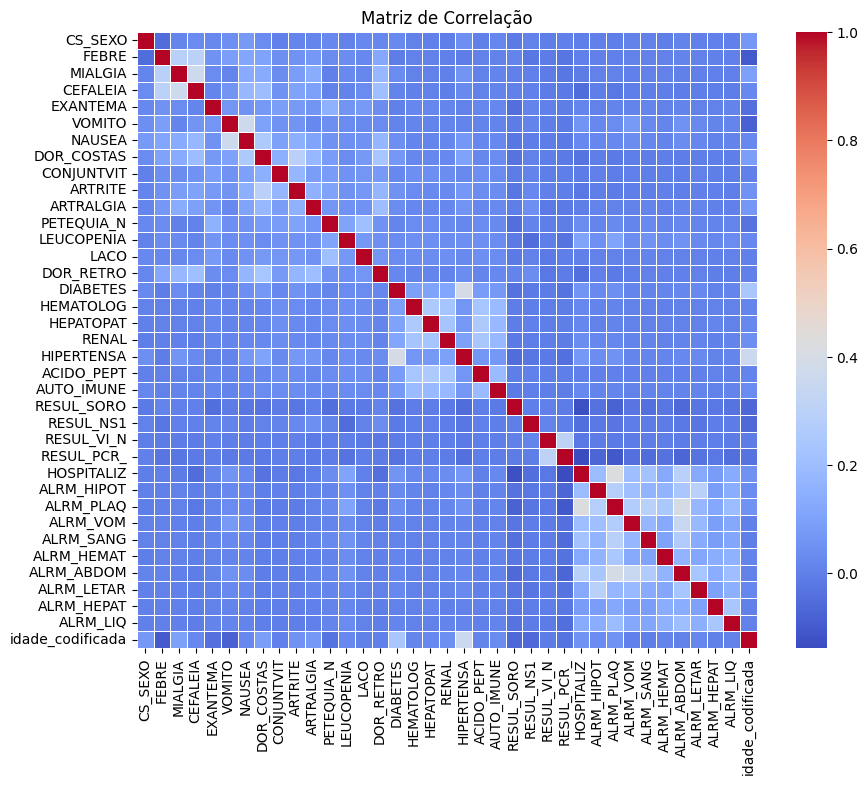

In [ ]:
import seaborn as sns
# Visualização da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação')
plt.show()

In [1]:
df_novo.scatter.plot(x='HOSPITALIZ', y='ALRM_PLAQ')

NameError: name 'df_novo' is not defined

In [ ]:
#sns.pairplot(df_novo)

In [ ]:
#df_novo.hist(figsize=(20, 15))

In [ ]:
#grafico de espalhamento
#from pandas.plotting import scatter_matrix
#attributes = ['HOSPITALIZ', 'ALRM_PLAQ','ALRM_ABDOM','ALRM_SANG','ALRM_VOM','ALRM_HIPOT','ALRM_LIQ','ALRM_HEMAT','ALRM_LETAR']
#scatter_matrix(df_novo[attributes], figsize=(12, 8))

In [ ]:
#df_novo.plot(kind='scatter', x='HOSPITALIZ', y='ALRM_PLAQ', alpha=0.1)
#plt.axis([0, 1, 0, 1])